In [1]:
"""
=======================
Loads trained models + test data from Feature_Selected_Retrain artifacts.
Produces per-model calibration curves, ECE scores, Brier scores, and a
combined overlay plot. Purely diagnostic — no model changes.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import warnings
from scipy.sparse import load_npz
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score

warnings.filterwarnings('ignore')

In [2]:
# =============================================================
# CONFIG
# =============================================================
ARTIFACT_DIR = "shap_artifacts_feature_selected"
K_FOLDS = 5
N_BINS = 10
STRATEGY = 'uniform'        # 'uniform' = equal-width bins, 'quantile' = equal-count
OUTPUT_DIR = "calibration_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# =============================================================
# HELPERS
# =============================================================
def expected_calibration_error(y_true, y_prob, n_bins=10, strategy='uniform'):
    """Weighted mean |accuracy - confidence| across bins."""
    fraction_pos, mean_pred = calibration_curve(
        y_true, y_prob, n_bins=n_bins, strategy=strategy
    )
    # calibration_curve can return fewer bins if some are empty
    # recompute bin counts for weighting
    if strategy == 'uniform':
        bins = np.linspace(0, 1, n_bins + 1)
    else:
        quantiles = np.linspace(0, 100, n_bins + 1)
        bins = np.percentile(y_prob, quantiles)
        bins[0] = 0.0
        bins[-1] = 1.0 + 1e-8

    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    bin_counts = np.bincount(bin_indices, minlength=n_bins)
    # only count bins that calibration_curve returned
    n_returned = len(fraction_pos)
    nonempty = bin_counts[bin_counts > 0][:n_returned]
    total = nonempty.sum()

    if total == 0:
        return 0.0
    ece = np.sum(nonempty * np.abs(fraction_pos - mean_pred)) / total
    return ece


def load_model(model_name, fold_idx):
    """Load a model from the artifact dir."""
    path = os.path.join(ARTIFACT_DIR, f"{model_name}_fold{fold_idx}.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)


def get_probs(model_name, model, X_test):
    """Get P(class=1) predictions, handling lasso's scaler."""
    if model_name == 'lasso':
        lasso_model, scaler = model
        X_scaled = scaler.transform(X_test)
        return lasso_model.predict_proba(X_scaled)[:, 1]
    else:
        return model.predict_proba(X_test)[:, 1]

In [4]:
# =============================================================
# LOAD DATA + MODELS
# =============================================================
print("=" * 60)
print("LOADING ARTIFACTS")
print("=" * 60)

feature_cols = np.load(os.path.join(ARTIFACT_DIR, "feature_cols.npy"), allow_pickle=True)
print(f"Features: {len(feature_cols)}")

MODEL_SPECS = [
    ('dt',       'Decision Tree', '#2196F3'),
    ('lasso',    'Lasso',         '#FF5722'),
    ('xgb',      'XGBoost',       '#9C27B0'),
    ('rf_tuned', 'Tuned RF',      '#4CAF50'),
]

# load all folds' test data
test_data = []
for i in range(K_FOLDS):
    X = load_npz(os.path.join(ARTIFACT_DIR, f"X_test_fold{i}.npz"))
    y = np.load(os.path.join(ARTIFACT_DIR, f"y_test_fold{i}.npy"))
    test_data.append((X, y))
    print(f"  Fold {i}: {X.shape[0]} samples (pos={y.sum()})")

LOADING ARTIFACTS
Features: 149
  Fold 0: 42189 samples (pos=16)
  Fold 1: 42188 samples (pos=15)
  Fold 2: 42188 samples (pos=15)
  Fold 3: 42188 samples (pos=15)
  Fold 4: 42188 samples (pos=15)


In [5]:
# =============================================================
# COMPUTE CALIBRATION STATS — ALL MODELS, ALL FOLDS
# =============================================================
print("\n" + "=" * 60)
print("CALIBRATION ANALYSIS")
print("=" * 60)

results = []  # collect everything for summary table

for model_key, model_name, color in MODEL_SPECS:
    print(f"\n--- {model_name} ---")

    fold_eces = []
    fold_briers = []
    fold_aucs = []

    for fold_idx in range(K_FOLDS):
        model = load_model(model_key, fold_idx)
        X_test, y_test = test_data[fold_idx]

        y_prob = get_probs(model_key, model, X_test)

        ece = expected_calibration_error(y_test, y_prob, N_BINS, STRATEGY)
        brier = brier_score_loss(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)

        fold_eces.append(ece)
        fold_briers.append(brier)
        fold_aucs.append(auc)

        print(f"  Fold {fold_idx}: ECE={ece:.4f}  Brier={brier:.4f}  AUC={auc:.4f}")

    results.append({
        'model': model_name,
        'ece_mean': np.mean(fold_eces),
        'ece_std': np.std(fold_eces),
        'brier_mean': np.mean(fold_briers),
        'brier_std': np.std(fold_briers),
        'auc_mean': np.mean(fold_aucs),
        'auc_std': np.std(fold_aucs),
    })

    print(f"  Mean:  ECE={np.mean(fold_eces):.4f}±{np.std(fold_eces):.4f}  "
          f"Brier={np.mean(fold_briers):.4f}±{np.std(fold_briers):.4f}  "
          f"AUC={np.mean(fold_aucs):.4f}±{np.std(fold_aucs):.4f}")

# summary table
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(OUTPUT_DIR, "calibration_summary.csv"), index=False)
print(f"\nSaved: calibration_summary.csv")


CALIBRATION ANALYSIS

--- Decision Tree ---
  Fold 0: ECE=0.0636  Brier=0.0548  AUC=0.7815
  Fold 1: ECE=0.1447  Brier=0.1119  AUC=0.6890
  Fold 2: ECE=0.1401  Brier=0.1181  AUC=0.6116
  Fold 3: ECE=0.1149  Brier=0.0909  AUC=0.5953
  Fold 4: ECE=0.1335  Brier=0.1055  AUC=0.7739
  Mean:  ECE=0.1194±0.0297  Brier=0.0962±0.0226  AUC=0.6903±0.0781

--- Lasso ---
  Fold 0: ECE=0.0543  Brier=0.0376  AUC=0.8978
  Fold 1: ECE=0.0763  Brier=0.0516  AUC=0.7254
  Fold 2: ECE=0.0791  Brier=0.0517  AUC=0.6924
  Fold 3: ECE=0.0740  Brier=0.0491  AUC=0.8927
  Fold 4: ECE=0.0745  Brier=0.0491  AUC=0.7526
  Mean:  ECE=0.0716±0.0088  Brier=0.0478±0.0052  AUC=0.7922±0.0863

--- XGBoost ---
  Fold 0: ECE=0.0035  Brier=0.0012  AUC=0.8701
  Fold 1: ECE=0.0045  Brier=0.0019  AUC=0.8119
  Fold 2: ECE=0.0035  Brier=0.0013  AUC=0.8586
  Fold 3: ECE=0.0034  Brier=0.0013  AUC=0.7347
  Fold 4: ECE=0.0037  Brier=0.0015  AUC=0.8103
  Mean:  ECE=0.0037±0.0004  Brier=0.0014±0.0002  AUC=0.8171±0.0477

--- Tuned RF ---


PLOTTING: COMBINED CALIBRATION (last fold)


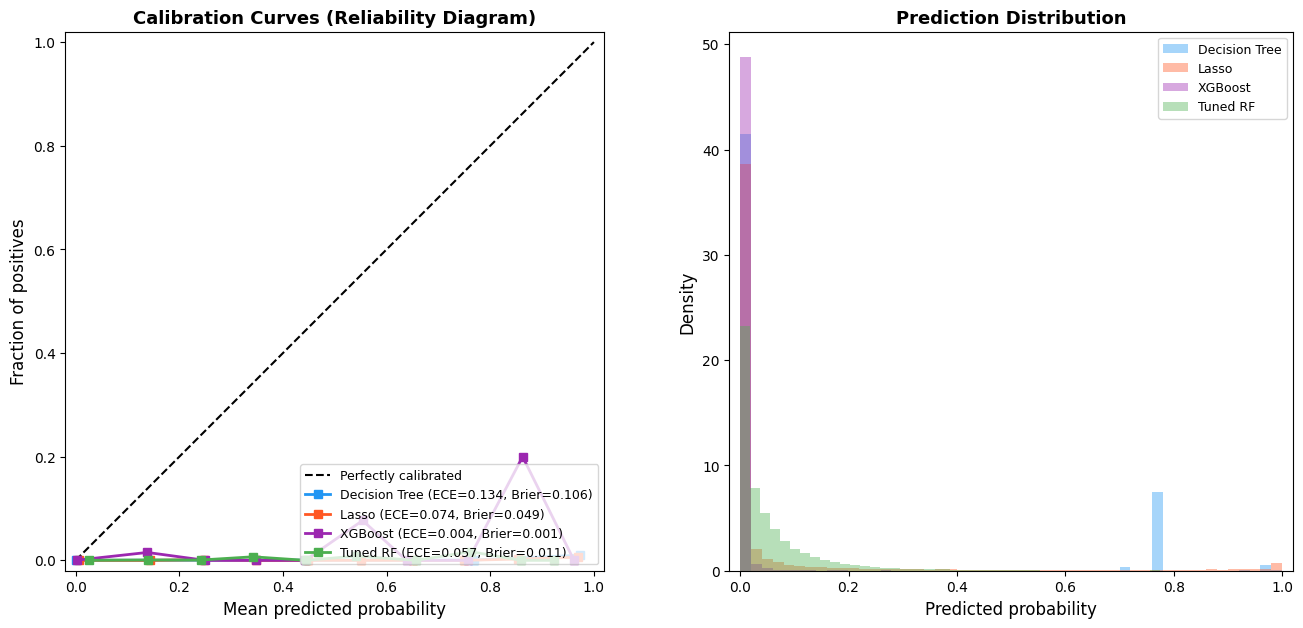

Saved: calibration_combined_lastfold.png


In [6]:
# =============================================================
# PLOT 1: COMBINED CALIBRATION CURVES (last fold)
# =============================================================
print("\n" + "=" * 60)
print("PLOTTING: COMBINED CALIBRATION (last fold)")
print("=" * 60)

LAST_FOLD = K_FOLDS - 1
X_last, y_last = test_data[LAST_FOLD]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# left: calibration curves
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfectly calibrated')

for model_key, model_name, color in MODEL_SPECS:
    model = load_model(model_key, LAST_FOLD)
    y_prob = get_probs(model_key, model, X_last)

    fraction_pos, mean_pred = calibration_curve(y_last, y_prob, n_bins=N_BINS, strategy=STRATEGY)
    ece = expected_calibration_error(y_last, y_prob, N_BINS, STRATEGY)
    brier = brier_score_loss(y_last, y_prob)

    ax.plot(mean_pred, fraction_pos, 's-', color=color, lw=2,
            label=f'{model_name} (ECE={ece:.3f}, Brier={brier:.3f})')

ax.set_xlabel('Mean predicted probability', fontsize=12)
ax.set_ylabel('Fraction of positives', fontsize=12)
ax.set_title('Calibration Curves (Reliability Diagram)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect('equal')

# right: prediction histograms
ax2 = axes[1]
for model_key, model_name, color in MODEL_SPECS:
    model = load_model(model_key, LAST_FOLD)
    y_prob = get_probs(model_key, model, X_last)
    ax2.hist(y_prob, bins=50, alpha=0.4, color=color, label=model_name, density=True)

ax2.set_xlabel('Predicted probability', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Prediction Distribution', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.set_xlim([-0.02, 1.02])

plt.show()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_combined_lastfold.png"),
            dpi=150, bbox_inches='tight')
plt.close()
print("Saved: calibration_combined_lastfold.png")

In [7]:
# =============================================================
# PLOT 2: PER-MODEL CALIBRATION ACROSS ALL FOLDS
# =============================================================
print("\n" + "=" * 60)
print("PLOTTING: PER-MODEL CALIBRATION (all folds)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

for idx, (model_key, model_name, color) in enumerate(MODEL_SPECS):
    ax = axes[idx]
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5)

    for fold_idx in range(K_FOLDS):
        model = load_model(model_key, fold_idx)
        X_test, y_test = test_data[fold_idx]
        y_prob = get_probs(model_key, model, X_test)

        fraction_pos, mean_pred = calibration_curve(
            y_test, y_prob, n_bins=N_BINS, strategy=STRATEGY
        )
        ece = expected_calibration_error(y_test, y_prob, N_BINS, STRATEGY)

        ax.plot(mean_pred, fraction_pos, 'o-', alpha=0.6,
                label=f'Fold {fold_idx} (ECE={ece:.3f})')

    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold', color=color)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])
    ax.set_aspect('equal')


plt.suptitle('Calibration Curves — All Models × All Folds', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_per_model_allfolds.png"),
            dpi=150, bbox_inches='tight')
plt.close()
print("Saved: calibration_per_model_allfolds.png")


PLOTTING: PER-MODEL CALIBRATION (all folds)
Saved: calibration_per_model_allfolds.png



PLOTTING: ECE + BRIER COMPARISON


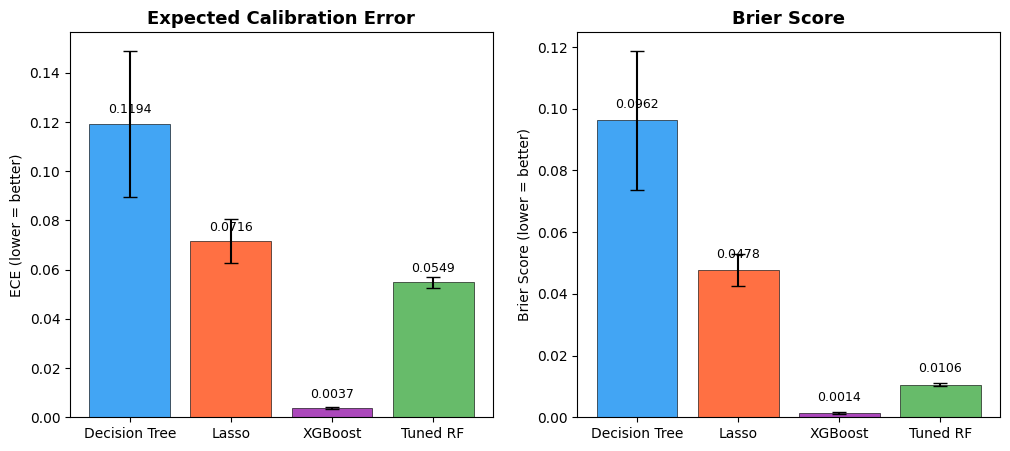

Saved: calibration_ece_brier_comparison.png


In [8]:
# =============================================================
# PLOT 3: ECE + BRIER COMPARISON BAR CHART
# =============================================================
print("\n" + "=" * 60)
print("PLOTTING: ECE + BRIER COMPARISON")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

model_names = [r['model'] for r in results]
colors = ['#2196F3', '#FF5722', '#9C27B0', '#4CAF50']
x = np.arange(len(model_names))

# ECE
ax = axes[0]
ece_means = [r['ece_mean'] for r in results]
ece_stds = [r['ece_std'] for r in results]
bars = ax.bar(x, ece_means, yerr=ece_stds, color=colors, alpha=0.85,
              capsize=5, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('ECE (lower = better)')
ax.set_title('Expected Calibration Error', fontsize=13, fontweight='bold')
for bar, val in zip(bars, ece_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# Brier
ax = axes[1]
brier_means = [r['brier_mean'] for r in results]
brier_stds = [r['brier_std'] for r in results]
bars = ax.bar(x, brier_means, yerr=brier_stds, color=colors, alpha=0.85,
              capsize=5, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Brier Score (lower = better)')
ax.set_title('Brier Score', fontsize=13, fontweight='bold')
for bar, val in zip(bars, brier_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.show()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "calibration_ece_brier_comparison.png"),
            dpi=150, bbox_inches='tight')
plt.close()
print("Saved: calibration_ece_brier_comparison.png")

In [9]:
# =============================================================
# DONE
# =============================================================
print("\n" + "=" * 60)
print("ALL OUTPUTS")
print("=" * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fsize = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    print(f"  {fname:50s} ({fsize/1024:.1f} KB)")

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)


ALL OUTPUTS
  calibration_combined_lastfold.png                  (4.6 KB)
  calibration_ece_brier_comparison.png               (4.6 KB)
  calibration_per_model_allfolds.png                 (227.9 KB)
  calibration_summary.csv                            (0.6 KB)

DONE
